### Импорт библиотек

In [48]:
import os
import random
import numpy as np
import cv2
import tensorflow as tf
from tensorflow import keras
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, f1_score
import matplotlib.pyplot as plt

# reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


### Загрузка датасета

In [49]:
IMG_HEIGHT = 96
IMG_WIDTH = 96
DATA_DIR = "../dataset"

classes = ["other", "person"]  # 0=other, 1=person

X, y = [], []

for label, cls in enumerate(classes):
    folder = os.path.join(DATA_DIR, cls)
    for fname in os.listdir(folder):
        path = os.path.join(folder, fname)
        img = cv2.imread(path, cv2.IMREAD_GRAYSCALE)
        if img is None:
            continue
        img = cv2.resize(img, (IMG_WIDTH, IMG_HEIGHT))
        X.append(img.astype(np.float32) / 255.0)
        y.append(label)

X = np.array(X).reshape(-1, IMG_HEIGHT, IMG_WIDTH, 1)
y = np.array(y)

print("Loaded:", X.shape, "labels:", y.shape)


Loaded: (162, 96, 96, 1) labels: (162,)


### Разделение train/test/val (70/15/15)

In [50]:
X_train, X_tmp, y_train, y_tmp = train_test_split(
    X, y, test_size=0.30, stratify=y, random_state=SEED
)

X_val, X_test, y_val, y_test = train_test_split(
    X_tmp, y_tmp, test_size=0.50, stratify=y_tmp, random_state=SEED
)

print("Train:", X_train.shape)
print("Val:", X_val.shape)
print("Test:", X_test.shape)


Train: (113, 96, 96, 1)
Val: (24, 96, 96, 1)
Test: (25, 96, 96, 1)


### Лёгкая CNN для микроконтроллера (GAP + sigmoid)

In [51]:
model = keras.models.Sequential([
    keras.layers.Conv2D(8, (3,3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 1)),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(16, (3,3), activation='relu'),
    keras.layers.MaxPooling2D((2,2)),
    keras.layers.Conv2D(32, (3,3), activation='relu'),
    keras.layers.GlobalAveragePooling2D(),
    keras.layers.Dense(8, activation='relu'),
    keras.layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


c:\Users\user\Desktop\tinyml\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_9 (Conv2D)               │ (None, 94, 94, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 47, 47, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 45, 45, 16)     │         1,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 22, 22, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 20, 20, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_3      │ (None, 32)             │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           264 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,161 (24.07 KB)

 Trainable params: 6,161 (24.07 KB)

 Non-trainable params: 0 (0.00 B)

### Обучение

In [52]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    batch_size=8,
    validation_data=(X_val, y_val)
)


Epoch 1/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 22ms/step - accuracy: 0.4779 - loss: 0.6933 - val_accuracy: 0.5000 - val_loss: 0.6907
Epoch 2/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5044 - loss: 0.6884 - val_accuracy: 0.5000 - val_loss: 0.6856
Epoch 3/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5044 - loss: 0.6764 - val_accuracy: 0.5000 - val_loss: 0.6656
Epoch 4/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5664 - loss: 0.6447 - val_accuracy: 0.6250 - val_loss: 0.6115
Epoch 5/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7699 - loss: 0.5706 - val_accuracy: 0.9167 - val_loss: 0.4978
Epoch 6/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7788 - loss: 0.5062 - val_accuracy: 0.7917 - val_loss: 0.4556
Epoch 7/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8230 - loss: 0.4582 - val_accuracy: 0.7917 - val_loss: 0.4009
Epoch 8/20
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8496 - loss: 0.4086 - val_accuracy: 0.9167 - v

#### Графики

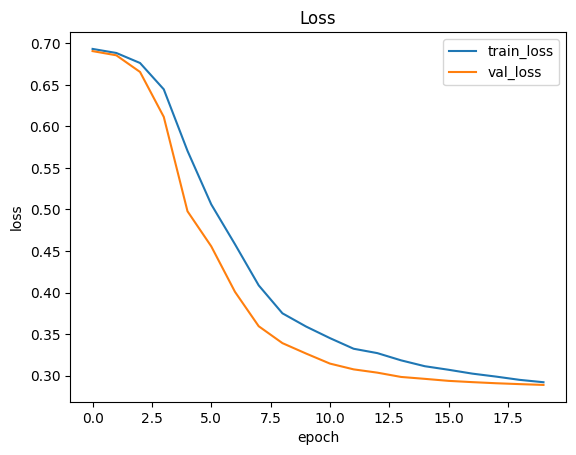

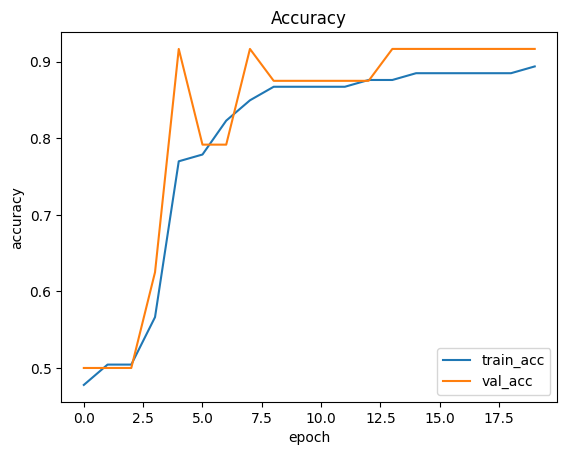

In [53]:
plt.figure()
plt.plot(history.history["loss"], label="train_loss")
plt.plot(history.history["val_loss"], label="val_loss")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("loss")
plt.title("Loss")
plt.show()

plt.figure()
plt.plot(history.history["accuracy"], label="train_acc")
plt.plot(history.history["val_accuracy"], label="val_acc")
plt.legend()
plt.xlabel("epoch")
plt.ylabel("accuracy")
plt.title("Accuracy")
plt.show()


#### Финальная оценка на тесте

In [54]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print("Final FP32 test accuracy:", test_acc)

Final FP32 test accuracy: 0.9599999785423279


#### Сохранение FP32 модели

In [55]:
model.save("person_classifier.h5")

### Квантизация INT8

In [56]:
def representative_data_gen():
    for i in range(100):
        idx = np.random.randint(0, len(X_train))
        img = X_train[idx:idx+1]
        yield [img.astype(np.float32)]


In [57]:
model_fp32 = tf.keras.models.load_model("person_classifier.h5")

converter = tf.lite.TFLiteConverter.from_keras_model(model_fp32)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_data_gen
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_int8 = converter.convert()

with open("person_classifier_int8.tflite", "wb") as f:
    f.write(tflite_int8)


INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmpolr7ducw\assets


INFO:tensorflow:Assets written to: C:\Users\user\AppData\Local\Temp\tmpolr7ducw\assets


Saved artifact at 'C:\Users\user\AppData\Local\Temp\tmpolr7ducw'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 96, 96, 1), dtype=tf.float32, name='input_layer_3')
Output Type:
  TensorSpec(shape=(None, 1), dtype=tf.float32, name=None)
Captures:
  2413866228176: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2413866230096: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2413866227984: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2413866232208: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2413866232400: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2413866230288: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2413865139088: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2413865135248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2413865138512: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2413865138320: TensorSpec(shape=(), dtype=tf.resource, name=None)


c:\Users\user\Desktop\tinyml\.venv\Lib\site-packages\tensorflow\lite\python\convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


### Сравнение FP32 vs INT8
#### FP32 предсказания

In [58]:
preds_fp32 = model_fp32.predict(X_test)
y_pred_fp32 = (preds_fp32[:,0] > 0.5).astype(np.int32)

acc_fp32 = np.mean(y_pred_fp32 == y_test)
print("FP32 accuracy:", acc_fp32)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
FP32 accuracy: 0.96


#### INT8 предсказания

In [59]:
interpreter = tf.lite.Interpreter(model_path="person_classifier_int8.tflite")
interpreter.allocate_tensors()

input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

in_scale, in_zero = input_details[0]['quantization']
out_scale, out_zero = output_details[0]['quantization']

def predict_int8(img):
    img_q = img / in_scale + in_zero
    img_q = np.clip(img_q, -128, 127).astype(np.int8)
    img_q = img_q.reshape(1, 96, 96, 1)

    interpreter.set_tensor(input_details[0]['index'], img_q)
    interpreter.invoke()

    out = interpreter.get_tensor(output_details[0]['index'])[0]
    out_fp32 = (out.astype(np.float32) - out_zero) * out_scale
    return out_fp32


c:\Users\user\Desktop\tinyml\.venv\Lib\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


In [60]:
y_pred_int8 = []
for img in X_test:
    p = predict_int8(img)[0]
    y_pred_int8.append(int(p > 0.5))

y_pred_int8 = np.array(y_pred_int8)
acc_int8 = np.mean(y_pred_int8 == y_test)

print("INT8 accuracy:", acc_int8)


INT8 accuracy: 0.96


### F1

In [61]:
print("FP32 confusion:\n", confusion_matrix(y_test, y_pred_fp32))
print("INT8 confusion:\n", confusion_matrix(y_test, y_pred_int8))

print("FP32 F1:", f1_score(y_test, y_pred_fp32))
print("INT8 F1:", f1_score(y_test, y_pred_int8))


FP32 confusion:
 [[13  0]
 [ 1 11]]
INT8 confusion:
 [[13  0]
 [ 1 11]]
FP32 F1: 0.9565217391304348
INT8 F1: 0.9565217391304348


In [1]:
import sys

input_file = "person_classifier_int8.tflite"
output_file = "model_int8.h"

with open(input_file, "rb") as f:
    data = f.read()

with open(output_file, "w") as f:
    f.write("const unsigned char model[] = {")
    for i, b in enumerate(data):
        if i % 12 == 0:
            f.write("\n  ")
        f.write(f"0x{b:02x}, ")
    f.write("\n};\n")
    f.write(f"const int model_len = {len(data)};\n")

print("Saved model_int8.h")


Saved model_int8.h
